In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Project root - going up one level from notebooks/ give us the repo root
PROJECT_ROOT = Path.cwd().parent
RAW_DATA = PROJECT_ROOT / "data" / "raw" / "2026-04-21_elist_data_cleaned.xlsx"

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data file: {RAW_DATA}")
print(f"File exists: {RAW_DATA.exists()}")
print(f"File size: {RAW_DATA.stat().st_size / 1024 / 1024:.1f} MB")

con = duckdb.connect(":memory:")
print(f"\nDuckDB version: {duckdb.__version__}")

Project root: C:\data-projects\cohort-retention
Raw data file: C:\data-projects\cohort-retention\data\raw\2026-04-21_elist_data_cleaned.xlsx
File exists: True
File size: 18.0 MB

DuckDB version: 1.5.2


In [2]:
# Read both sheets from the Excel file into pandas
df_orders = pd.read_excel(RAW_DATA, sheet_name="orders_data_cleaned")
df_lookup = pd.read_excel(RAW_DATA, sheet_name="country_lookup_raw")

# Register the DataFrames as DuckDB tables (zero-copy: just a pointer(Index), not a duplicate)
con.register("orders_raw", df_orders)
con.register("country_lookup_raw", df_lookup)

# Confirm shapes
print(f"orders_raw:         {len(df_orders):>7,} rows × {len(df_orders.columns)} columns")
print(f"country_lookup_raw: {len(df_lookup):>7,} rows × {len(df_lookup.columns)} columns")

orders_raw:         108,127 rows × 26 columns
country_lookup_raw:     193 rows × 2 columns


In [3]:
# Ask DuckDB to describe the structure of the orders_raw table
con.sql("DESCRIBE orders_raw").show()

┌─────────────────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│           column_name           │ column_type │  null   │   key   │ default │  extra  │
│             varchar             │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ USER_ID                         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ ORDER_ID                        │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ PURCHASE_TS                     │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ PURCHASE_TS_cleaned             │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ SHIP_TS                         │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ DELIVERY_TS                     │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ REFUND_TS                       │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ REFUND_T

In [4]:
# Show 5 sample rows from orders_raw
con.sql("SELECT * FROM orders_raw LIMIT 5").df()

,USER_ID,ORDER_ID,PURCHASE_TS,PURCHASE_TS_cleaned,SHIP_TS,DELIVERY_TS,REFUND_TS,REFUND_TS_cleaned,REFUND_TS_sanity check,PRODUCT_NAME,...,CURRENCY,PURCHASE_PLATFORM,MARKETING_CHANNEL,MARKETING_CHANNEL_cleaned,ACCOUNT_CREATION_METHOD,ACCOUNT_CREATION_METHOD_cleaned,COUNTRY_CODE,COUNTRY_CODE_cleaned,LOYALTY_PROGRAM,CREATED_ON
0,24560,5f87a27686c1,2021-04-20,2021-04-20,2021-04-23,2021-04-26,NaT,NaT,None,27in 4K gaming monitor,...,JPY,website,email,None,mobile,NaN,JP,JP,1,2021-02-25
1,62488,5c404f671902,2022-05-27,2022-05-27,2022-05-29,2022-06-06,NaT,NaT,None,Samsung Charging Cable Pack,...,USD,website,direct,None,desktop,NaN,US,US,0,2022-02-20
2,74155,424e94e485f3,2022-12-14,2022-12-14,2022-12-15,2022-12-19,NaT,NaT,None,Apple Airpods Headphones,...,EUR,website,direct,None,desktop,NaN,IT,IT,0,2019-07-13
3,122725,6ebc18196ce4,2019-01-31,2019-01-31,2019-02-02,2019-02-07,NaT,NaT,None,Samsung Charging Cable Pack,...,USD,mobile app,email,None,mobile,NaN,US,US,0,2019-01-22
4,134439,1cea3298ca35,2021-03-14,2021-03-14,2021-03-17,2021-03-23,NaT,NaT,None,Apple Airpods Headphones,...,USD,website,direct,None,desktop,NaN,US,US,1,2021-01-20


In [5]:
# Look at sample rows with only the columns relevant to cohort analysis
con.sql("""
    SELECT
        USER_ID,
        ORDER_ID,
        PURCHASE_TS_cleaned,
        CREATED_ON,
        PRODUCT_NAME,
        COUNTRY_CODE_cleaned,
        PURCHASE_PLATFORM,
        LOYALTY_PROGRAM,
        USD_PRICE_cleaned
    FROM orders_raw
    LIMIT 5
""").df()

,USER_ID,ORDER_ID,PURCHASE_TS_cleaned,CREATED_ON,PRODUCT_NAME,COUNTRY_CODE_cleaned,PURCHASE_PLATFORM,LOYALTY_PROGRAM,USD_PRICE_cleaned
0,24560,5f87a27686c1,2021-04-20,2021-02-25,27in 4K gaming monitor,JP,website,1,434.05
1,62488,5c404f671902,2022-05-27,2022-02-20,Samsung Charging Cable Pack,US,website,0,24.00
2,74155,424e94e485f3,2022-12-14,2019-07-13,Apple Airpods Headphones,IT,website,0,103.13
3,122725,6ebc18196ce4,2019-01-31,2019-01-22,Samsung Charging Cable Pack,US,mobile app,0,24.28
4,134439,1cea3298ca35,2021-03-14,2021-01-20,Apple Airpods Headphones,US,website,1,168.00


In [6]:
# Establish the date range of our data and basic counts
con.sql("""
    SELECT
        MIN(PURCHASE_TS_cleaned) AS earliest_purchase,
        MAX(PURCHASE_TS_cleaned) AS latest_purchase,
        DATE_DIFF('month', MIN(PURCHASE_TS_cleaned), MAX(PURCHASE_TS_cleaned)) AS span_months,
        COUNT(DISTINCT USER_ID) AS unique_users,
        COUNT(*) AS total_orders
    FROM orders_raw
""").df()

,earliest_purchase,latest_purchase,span_months,unique_users,total_orders
0,2019-01-01,2022-12-31,47,87628,108127


In [7]:
# Data quality checks: are there any nulls, duplicates, or impossible dates
# that would silently break our cohort analysis?
con.sql("""
    SELECT
        SUM(CASE WHEN USER_ID IS NULL THEN 1 ELSE 0 END) AS null_user_ids,
        SUM(CASE WHEN PURCHASE_TS_cleaned IS NULL THEN 1 ELSE 0 END) AS null_purchase_dates,
        SUM(CASE WHEN ORDER_ID IS NULL THEN 1 ELSE 0 END) AS null_order_ids,
        COUNT(*) - COUNT(DISTINCT ORDER_ID) AS duplicate_order_ids,
        SUM(CASE WHEN PURCHASE_TS_cleaned > CURRENT_DATE THEN 1 ELSE 0 END) AS future_dated_orders
    FROM orders_raw
""").df()

,null_user_ids,null_purchase_dates,null_order_ids,duplicate_order_ids,future_dated_orders
0,0.0,3.0,0.0,0,0.0


In [8]:
# Look at the 3 orders missing PURCHASE_TS_cleaned to understand what's going on
con.sql("""
    SELECT
        USER_ID,
        ORDER_ID,
        PURCHASE_TS_cleaned,
        CREATED_ON,
        PRODUCT_NAME,
        COUNTRY_CODE_cleaned,
        USD_PRICE_cleaned
    FROM orders_raw
    WHERE PURCHASE_TS_cleaned IS NULL
""").df()

,USER_ID,ORDER_ID,PURCHASE_TS_cleaned,CREATED_ON,PRODUCT_NAME,COUNTRY_CODE_cleaned,USD_PRICE_cleaned
0,a5298a4d,0dda212aaea69940,NaT,2019-07-22,Samsung Charging Cable Pack,FR,21.96
1,a591f271,d591f9703fe70151,NaT,2018-12-26,Apple Airpods Headphones,US,168.00
2,c9b897f0,808df003fb785277,NaT,2020-07-09,Apple Airpods Headphones,US,168.00


In [9]:
con.sql("""
    CREATE OR REPLACE TABLE dim_users AS
    WITH ranked_orders AS (
        SELECT
            USER_ID,
            PURCHASE_TS_cleaned,
            COUNTRY_CODE_cleaned,
            PURCHASE_PLATFORM,
            PRODUCT_NAME,
            LOYALTY_PROGRAM,
            ROW_NUMBER() OVER (
                PARTITION BY USER_ID
                ORDER BY PURCHASE_TS_cleaned ASC
            ) AS order_rank
        FROM orders_raw
        WHERE PURCHASE_TS_cleaned IS NOT NULL
    )
    SELECT
        USER_ID,
        PURCHASE_TS_cleaned                      AS first_purchase_date,
        DATE_TRUNC('month', PURCHASE_TS_cleaned) AS first_purchase_month,
        COUNTRY_CODE_cleaned                     AS first_purchase_country,
        PURCHASE_PLATFORM                        AS first_purchase_platform,
        PRODUCT_NAME                             AS first_purchase_product,
        LOYALTY_PROGRAM                          AS loyalty_at_first_purchase
    FROM ranked_orders
    WHERE order_rank = 1
""")

con.sql("SELECT COUNT(*) AS user_count FROM dim_users").df()

,user_count
0,87625


In [10]:
con.sql("""
    SELECT
        COUNT(*)                                            AS total_rows,
        COUNT(DISTINCT USER_ID)                             AS unique_user_ids,
        COUNT(*) - COUNT(DISTINCT USER_ID)                  AS pk_duplicates,
        SUM(CASE WHEN first_purchase_month IS NULL THEN 1 ELSE 0 END) AS null_cohort_months,
        MIN(first_purchase_month)                           AS earliest_cohort,
        MAX(first_purchase_month)                           AS latest_cohort,
        COUNT(DISTINCT first_purchase_month)                AS distinct_cohorts
    FROM dim_users
""").df()

,total_rows,unique_user_ids,pk_duplicates,null_cohort_months,earliest_cohort,latest_cohort,distinct_cohorts
0,87625,87625,0,0.0,2019-01-01,2022-12-01,48


In [11]:
cohort_sizes = con.sql("""
    SELECT
        first_purchase_month AS cohort_month,
        COUNT(*) AS new_users
    FROM dim_users
    GROUP BY first_purchase_month
    ORDER BY first_purchase_month
""").df()

print(f"Cohorts: {len(cohort_sizes)}")
print(f"Smallest: {cohort_sizes['new_users'].min():,}")
print(f"Largest:  {cohort_sizes['new_users'].max():,}")
print(f"Median:   {int(cohort_sizes['new_users'].median()):,}")
print()
print(cohort_sizes.head(6))
print("...")
print(cohort_sizes.tail(6))

Cohorts: 48
Smallest: 625
Largest:  2,887
Median:   2,035

  cohort_month  new_users
0   2019-01-01       1237
1   2019-02-01       1096
2   2019-03-01       1213
3   2019-04-01       1172
4   2019-05-01       1130
5   2019-06-01       1027
...
   cohort_month  new_users
42   2022-07-01       1651
43   2022-08-01       1330
44   2022-09-01        919
45   2022-10-01        702
46   2022-11-01        651
47   2022-12-01        625


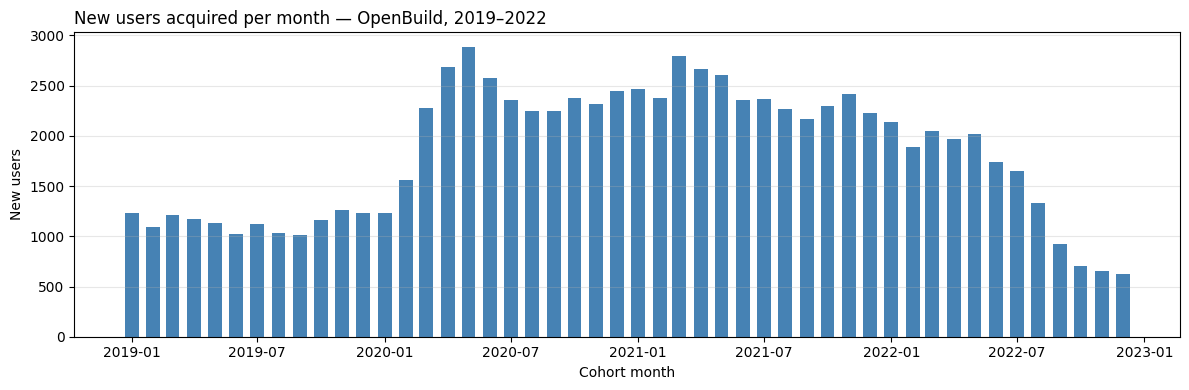

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(cohort_sizes['cohort_month'], cohort_sizes['new_users'],
       width=20, color='steelblue')
ax.set_title('New users acquired per month — OpenBuild, 2019–2022', loc='left')
ax.set_xlabel('Cohort month')
ax.set_ylabel('New users')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
cohort_retention = con.sql("""
    WITH user_orders AS (
        -- For each order, compute months since the user's first purchase
        SELECT
            o.USER_ID,
            u.first_purchase_month AS cohort_month,
            DATE_DIFF('month',
                      u.first_purchase_month,
                      DATE_TRUNC('month', o.PURCHASE_TS_cleaned)
            ) AS months_since_acquisition
        FROM orders_raw o
        INNER JOIN dim_users u USING (USER_ID)
        WHERE o.PURCHASE_TS_cleaned IS NOT NULL
    ),
    cohort_active_users AS (
        -- Count distinct users active in each (cohort, month-offset) cell
        SELECT
            cohort_month,
            months_since_acquisition,
            COUNT(DISTINCT USER_ID) AS active_users
        FROM user_orders
        GROUP BY cohort_month, months_since_acquisition
    ),
    cohort_size AS (
        -- Cohort size = active users at month 0 (everyone is active in their first month by definition)
        SELECT
            cohort_month,
            active_users AS cohort_size
        FROM cohort_active_users
        WHERE months_since_acquisition = 0
    )
    SELECT
        a.cohort_month,
        a.months_since_acquisition,
        a.active_users,
        s.cohort_size,
        ROUND(a.active_users * 100.0 / s.cohort_size, 2) AS retention_pct
    FROM cohort_active_users a
    INNER JOIN cohort_size s USING (cohort_month)
    ORDER BY a.cohort_month, a.months_since_acquisition
""").df()

print(f"Rows in cohort_retention: {len(cohort_retention):,}")
print(cohort_retention.head(10))

Rows in cohort_retention: 1,049
  cohort_month  months_since_acquisition  active_users  cohort_size  \
0   2019-01-01                         0          1237         1237   
1   2019-01-01                         1            13         1237   
2   2019-01-01                         2            10         1237   
3   2019-01-01                         3             9         1237   
4   2019-01-01                         4             4         1237   
5   2019-01-01                         5             5         1237   
6   2019-01-01                         6             1         1237   
7   2019-01-01                         7             2         1237   
8   2019-01-01                         8             3         1237   
9   2019-01-01                         9             4         1237   

   retention_pct  
0         100.00  
1           1.05  
2           0.81  
3           0.73  
4           0.32  
5           0.40  
6           0.08  
7           0.16  
8           0.2

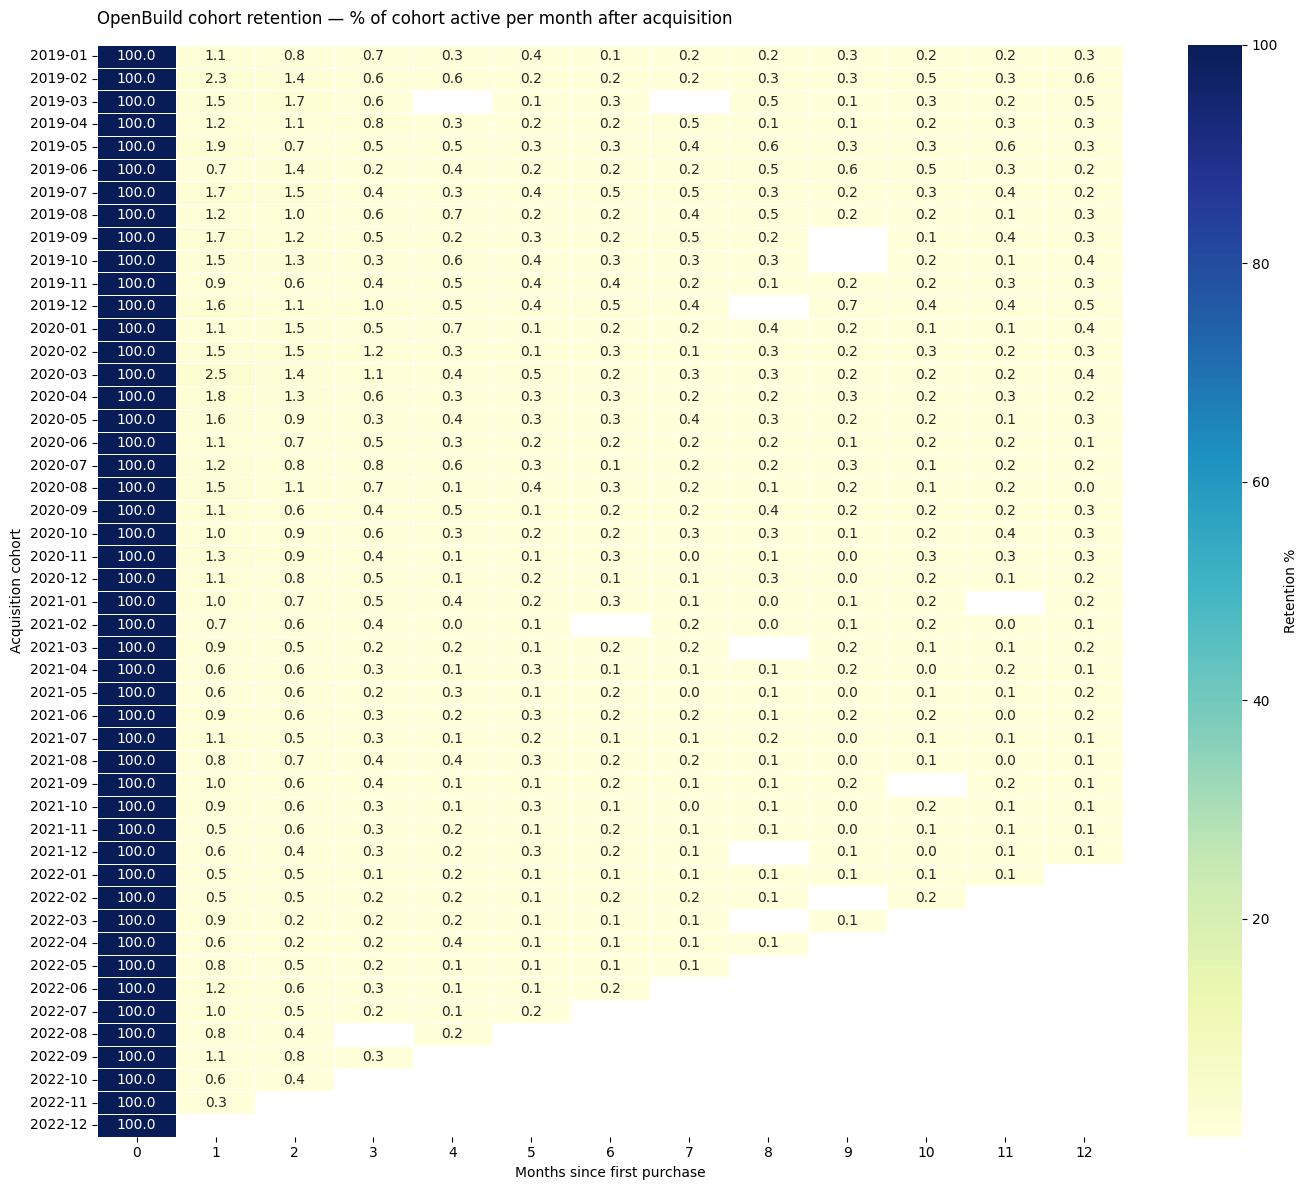

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot long → wide. Rows = cohort, columns = month offset, cells = retention %
retention_matrix = cohort_retention.pivot(
    index='cohort_month',
    columns='months_since_acquisition',
    values='retention_pct'
)

# Format the cohort_month index as 'YYYY-MM' (no timestamp clutter)
retention_matrix.index = retention_matrix.index.strftime('%Y-%m')

# Limit visible columns to months 0–12 to avoid right-censored noise
retention_matrix_12mo = retention_matrix.iloc[:, 0:13]

# Mask the right-censored region (cohorts past Dec 2021 can't be observed at month 12)
# We keep all cells but visually limit the heatmap to months 0–12
retention_matrix_12mo = retention_matrix.iloc[:, 0:13]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    retention_matrix_12mo,
    annot=True, fmt='.1f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Retention %'},
    ax=ax,
    linewidths=0.5,
    linecolor='white'
)
ax.set_title('OpenBuild cohort retention — % of cohort active per month after acquisition',
             loc='left', pad=15)
ax.set_xlabel('Months since first purchase')
ax.set_ylabel('Acquisition cohort')
plt.tight_layout()
plt.show()

In [16]:
con.sql("""
CREATE OR REPLACE TABLE stg_orders AS
SELECT
    USER_ID AS user_id,
    ORDER_ID AS order_id,
    PURCHASE_TS_cleaned AS purchase_ts,
    DATE_TRUNC('month', PURCHASE_TS_cleaned) AS purchase_month,
    REFUND_TS_cleaned AS refund_ts,
    SHIP_TS AS ship_ts,
    DELIVERY_TS AS delivery_ts,
    CREATED_ON AS account_created_on,
    PRODUCT_NAME AS product_name,
    PRODUCT_ID AS product_id,
    USD_PRICE_cleaned AS usd_price,
    PURCHASE_PLATFORM AS purchase_platform,
    COUNTRY_CODE_cleaned AS country_code,
    LOYALTY_PROGRAM AS is_loyalty_member,
    CASE WHEN REFUND_TS_cleaned IS NOT NULL THEN 1 ELSE 0 END AS is_refunded
FROM orders_raw
WHERE PURCHASE_TS_cleaned IS NOT NULL
""")

con.sql("""
SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT order_id) AS unique_orders,
    SUM(is_refunded) AS refunded_orders,
    ROUND(100.0 * SUM(is_refunded) / COUNT(*), 2) AS refund_rate_pct
FROM stg_orders
""").df()

,row_count,unique_orders,refunded_orders,refund_rate_pct
0,108124,108124,5379.0,4.97


In [17]:
con.sql("""
CREATE OR REPLACE TABLE dim_users AS
WITH ranked_orders AS (
    SELECT
        user_id,
        purchase_ts,
        purchase_month,
        country_code,
        purchase_platform,
        product_name,
        is_loyalty_member,
        ROW_NUMBER() OVER (
            PARTITION BY user_id
            ORDER BY purchase_ts ASC
        ) AS order_rank
    FROM stg_orders
)
SELECT
    user_id,
    purchase_ts                   AS first_purchase_date,
    purchase_month                AS first_purchase_month,
    country_code                  AS first_purchase_country,
    purchase_platform             AS first_purchase_platform,
    product_name                  AS first_purchase_product,
    is_loyalty_member             AS loyalty_at_first_purchase
FROM ranked_orders
WHERE order_rank = 1
""")

con.sql("""
SELECT
    COUNT(*) AS users,
    COUNT(*) - COUNT(DISTINCT user_id) AS pk_duplicates,
    MIN(first_purchase_month) AS earliest_cohort,
    MAX(first_purchase_month) AS latest_cohort
FROM dim_users
""").df()

,users,pk_duplicates,earliest_cohort,latest_cohort
0,87625,0,2019-01-01,2022-12-01


In [21]:
con.sql("""
CREATE OR REPLACE TABLE fct_orders AS
WITH ranked AS (
    SELECT
        o.*,
        u.first_purchase_date,
        u.first_purchase_month AS cohort_month,
        DATE_DIFF('month', u.first_purchase_month, o.purchase_month) AS months_since_acquisition,
        ROW_NUMBER() OVER (
            PARTITION BY o.user_id
            ORDER BY o.purchase_ts ASC, o.order_id ASC
        ) AS user_order_seq
    FROM stg_orders o
    INNER JOIN dim_users u USING (user_id)
)
SELECT
    order_id,
    user_id,
    purchase_ts,
    purchase_month,
    refund_ts,
    is_refunded,
    product_name,
    product_id,
    usd_price,
    purchase_platform,
    country_code,
    is_loyalty_member,
    first_purchase_date,
    cohort_month,
    months_since_acquisition,
    user_order_seq,
    CASE WHEN user_order_seq = 1 THEN 1 ELSE 0 END AS is_first_purchase
FROM ranked
""")

con.sql("""
SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT order_id) AS unique_orders,
    SUM(is_first_purchase) AS first_purchases,
    COUNT(DISTINCT user_id) AS unique_users,
    MIN(months_since_acquisition) AS min_offset,
    MAX(months_since_acquisition) AS max_offset
FROM fct_orders
""").df()

,row_count,unique_orders,first_purchases,unique_users,min_offset,max_offset
0,108124,108124,87625.0,87625,0,47


In [19]:
con.sql("""
SELECT
    user_id,
    purchase_ts,
    COUNT(*) AS orders_same_day
FROM stg_orders
GROUP BY user_id, purchase_ts
HAVING COUNT(*) > 1
ORDER BY orders_same_day DESC
LIMIT 5
""").df()

,user_id,purchase_ts,orders_same_day
0,005acbb4,2021-09-22,3
1,0230a621,2022-09-13,3
2,176b9c1b,2021-09-04,3
3,03d11796,2020-12-19,3
4,226d86f3,2022-09-22,3


In [22]:
con.sql("""
CREATE OR REPLACE TABLE mart_cohort_retention AS
WITH active_users AS (
    SELECT
        cohort_month,
        months_since_acquisition,
        COUNT(DISTINCT user_id) AS active_users
    FROM fct_orders
    GROUP BY cohort_month, months_since_acquisition
),
cohort_size AS (
    SELECT
        cohort_month,
        active_users AS cohort_size
    FROM active_users
    WHERE months_since_acquisition = 0
)
SELECT
    a.cohort_month,
    a.months_since_acquisition,
    a.active_users,
    s.cohort_size,
    ROUND(a.active_users * 100.0 / s.cohort_size, 2) AS retention_pct
FROM active_users a
INNER JOIN cohort_size s USING (cohort_month)
ORDER BY a.cohort_month, a.months_since_acquisition
""")

con.sql("""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT cohort_month) AS cohorts,
    MIN(retention_pct) AS min_retention,
    MAX(retention_pct) AS max_retention
FROM mart_cohort_retention
""").df()

,rows,cohorts,min_retention,max_retention
0,1049,48,0.03,100.0


In [23]:
tests = [
    # ---- stg_orders ----
    ("stg_orders.order_id is not null",
     "SELECT COUNT(*) AS failures FROM stg_orders WHERE order_id IS NULL"),
    ("stg_orders.order_id is unique",
     "SELECT COUNT(*) - COUNT(DISTINCT order_id) AS failures FROM stg_orders"),
    ("stg_orders.user_id is not null",
     "SELECT COUNT(*) AS failures FROM stg_orders WHERE user_id IS NULL"),
    ("stg_orders.purchase_ts is not null",
     "SELECT COUNT(*) AS failures FROM stg_orders WHERE purchase_ts IS NULL"),
    ("stg_orders.purchase_platform accepted values",
     "SELECT COUNT(*) AS failures FROM stg_orders WHERE purchase_platform NOT IN ('website', 'mobile app')"),
    ("stg_orders.is_refunded is 0 or 1",
     "SELECT COUNT(*) AS failures FROM stg_orders WHERE is_refunded NOT IN (0, 1)"),

    # ---- dim_users ----
    ("dim_users.user_id is unique",
     "SELECT COUNT(*) - COUNT(DISTINCT user_id) AS failures FROM dim_users"),
    ("dim_users.first_purchase_month is not null",
     "SELECT COUNT(*) AS failures FROM dim_users WHERE first_purchase_month IS NULL"),
    ("dim_users row count = stg_orders distinct users",
     """SELECT ABS((SELECT COUNT(*) FROM dim_users) -
                   (SELECT COUNT(DISTINCT user_id) FROM stg_orders)) AS failures"""),

    # ---- fct_orders ----
    ("fct_orders.order_id is unique",
     "SELECT COUNT(*) - COUNT(DISTINCT order_id) AS failures FROM fct_orders"),
    ("fct_orders.user_id references dim_users",
     """SELECT COUNT(*) AS failures FROM fct_orders f
        WHERE NOT EXISTS (SELECT 1 FROM dim_users u WHERE u.user_id = f.user_id)"""),
    ("fct_orders.is_first_purchase sums to user count",
     """SELECT ABS(SUM(is_first_purchase) - (SELECT COUNT(*) FROM dim_users)) AS failures
        FROM fct_orders"""),
    ("fct_orders.months_since_acquisition is non-negative",
     "SELECT COUNT(*) AS failures FROM fct_orders WHERE months_since_acquisition < 0"),

    # ---- mart_cohort_retention ----
    ("mart_cohort_retention.month-0 retention is always 100%",
     """SELECT COUNT(*) AS failures FROM mart_cohort_retention
        WHERE months_since_acquisition = 0 AND retention_pct <> 100.00"""),
    ("mart_cohort_retention.retention_pct is between 0 and 100",
     "SELECT COUNT(*) AS failures FROM mart_cohort_retention WHERE retention_pct < 0 OR retention_pct > 100"),
]

# Execute all tests
results = []
for name, sql in tests:
    failures = con.sql(sql).df().iloc[0, 0]
    status = "PASS" if failures == 0 else "FAIL"
    results.append({"test": name, "failures": int(failures), "status": status})

results_df = pd.DataFrame(results)
n_pass = (results_df['status'] == 'PASS').sum()
n_fail = (results_df['status'] == 'FAIL').sum()

print(f"{n_pass}/{len(results_df)} tests passed")
if n_fail > 0:
    print(f"⚠️  {n_fail} FAILURES:")
    print(results_df[results_df['status'] == 'FAIL'].to_string(index=False))
else:
    print("✅ All tests pass")

results_df

15/15 tests passed
✅ All tests pass


,test,failures,status
0,stg_orders.order_id is not null,0,PASS
1,stg_orders.order_id is unique,0,PASS
2,stg_orders.user_id is not null,0,PASS
3,stg_orders.purchase_ts is not null,0,PASS
4,stg_orders.purchase_platform accepted values,0,PASS
5,stg_orders.is_refunded is 0 or 1,0,PASS
6,dim_users.user_id is unique,0,PASS
7,dim_users.first_purchase_month is not null,0,PASS
8,dim_users row count = stg_orders distinct users,0,PASS
9,fct_orders.order_id is unique,0,PASS
